# Best use case: tidal analysis over a grid with `solve_many`

Many real datasets are a **field** of tidal time series that share one time base
— an ocean-model SSH grid, satellite altimetry, or an array of tide gauges / moorings.
The usual approach loops `utide.solve` over every cell, which is slow.

`solve_many` builds the harmonic model **once** and solves every cell in a single
(optionally GPU) batched call. Here we synthesize a tidal field on a 64×64 grid
(one year of hourly samples per cell), recover the constituent amplitude and phase
everywhere in one call, and plot the resulting M2 co-tidal maps.


In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np

import utide


## 1. A synthetic tidal field

Five constituents (M2, S2, N2, K1, O1) with spatially varying amplitude and phase,
plus a little observational noise. `X` has shape `(n_times, n_cells)`.


In [2]:
ny = nx = 64
ncell = ny * nx
nt = 365 * 24
t = np.arange(nt) / 24.0          # days
epoch = "2000-01-01"

yy, xx = np.meshgrid(np.linspace(0, 1, ny), np.linspace(0, 1, nx), indexing="ij")
xx = xx.ravel(); yy = yy.ravel()

cph = {"M2": 1/12.4206, "S2": 1/12.0, "N2": 1/12.6583, "K1": 1/23.9345, "O1": 1/25.8193}
amp = {"M2": 0.5 + 1.5*xx + 0.3*np.sin(2*np.pi*yy), "S2": 0.2 + 0.5*xx,
       "N2": 0.1 + 0.2*xx, "K1": 0.3 + 0.1*yy, "O1": 0.2 + 0.1*yy}
pha = {"M2": 360*yy % 360, "S2": (30+300*yy) % 360, "N2": (60+200*xx) % 360,
       "K1": (90+180*xx) % 360, "O1": (120+90*yy) % 360}

rng = np.random.default_rng(0)
X = np.zeros((nt, ncell))
for c in cph:
    arg = 2*np.pi*cph[c]*24*t[:, None] - np.deg2rad(pha[c])[None, :]
    X += amp[c][None, :] * np.cos(arg)
X += 0.03 * rng.standard_normal((nt, ncell))
X.shape


(8760, 4096)

## 2. Recover every cell in one `solve_many` call

`gpu=True` runs the basis construction and solve on the GPU (set it to `False`
to stay on the CPU — `solve_many` is a big win there too, just without the extra
GPU speed-up).


In [3]:
constit = list(cph)
kw = dict(lat=45, constit=constit, epoch=epoch, gpu=True, verbose=False)

utide.solve_many(t, X[:, :8], **kw)          # warm up the GPU kernels
t0 = time.perf_counter()
out = utide.solve_many(t, X, **kw)
gpu_t = time.perf_counter() - t0
print(f"solve_many: {ncell} cells in {gpu_t:.2f} s")


solve_many: 4096 cells in 1.27 s


How does that compare to looping `solve` over every cell? Time a handful and
extrapolate — and confirm the batched result matches the per-cell result exactly.


In [4]:
m2 = list(out.name).index("M2")
nsample = 20
sample_A = np.empty(nsample)
t0 = time.perf_counter()
for s in range(nsample):
    c = utide.solve(t, X[:, s], lat=45, constit=constit, method="ols",
                    conf_int="none", epoch=epoch, verbose=False)
    sample_A[s] = c["A"][list(c["name"]).index("M2")]
per_cell = (time.perf_counter() - t0) / nsample

print(f"per-cell solve(): {1000*per_cell:.0f} ms  ->  naive loop ~= {per_cell*ncell:.0f} s")
print(f"speed-up: {per_cell*ncell/gpu_t:.0f}x")
print(f"solve_many vs per-cell solve(): max rel diff = "
      f"{np.max(np.abs(sample_A - out.A[m2, :nsample]) / sample_A):.1e}")


per-cell solve(): 77 ms  ->  naive loop ~= 316 s
speed-up: 249x
solve_many vs per-cell solve(): max rel diff = 9.5e-15


## 3. Co-tidal maps

`out.A` and `out.g` are `(n_constituents, n_cells)`; reshape a row back to the grid.


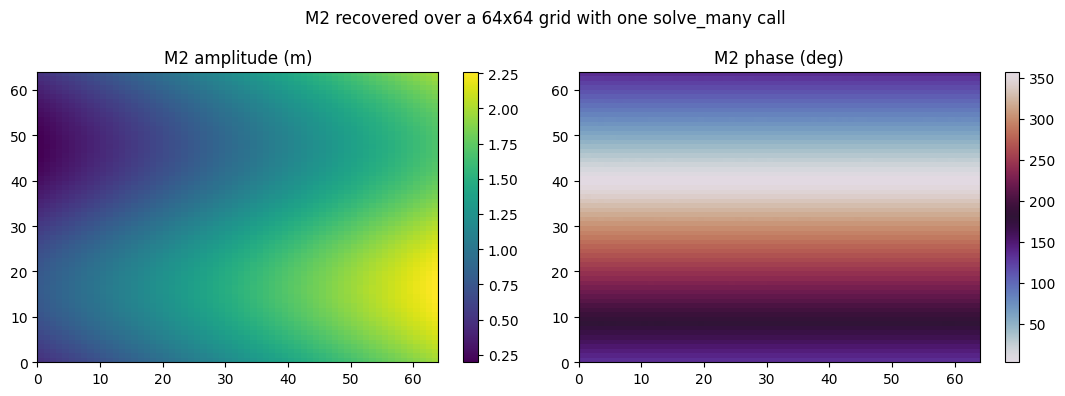

In [5]:
A_map = out.A[m2].reshape(ny, nx)
g_map = out.g[m2].reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im0 = ax[0].pcolormesh(A_map, shading="auto"); ax[0].set_title("M2 amplitude (m)")
fig.colorbar(im0, ax=ax[0])
im1 = ax[1].pcolormesh(g_map, shading="auto", cmap="twilight"); ax[1].set_title("M2 phase (deg)")
fig.colorbar(im1, ax=ax[1])
fig.suptitle(f"M2 recovered over a {ny}x{nx} grid with one solve_many call")
fig.tight_layout(); plt.show()


That co-amplitude / co-phase pair was extracted for **every** grid cell in one call.
Swap in your own `(n_times, n_cells)` array — model output, altimetry, a gauge array —
and `solve_many` returns the constituents everywhere. For velocity data pass `v=` too;
for first-pass screening of very large grids add `gpu_precision="single"`.
